# 06 – Random Forest

Nichtlineares Ensemble-Modell — Test auf H4 (nichtlinear > linear) und H3 (Zeitfeatures).

| Modell | Features |
|---|---|
| **Model A** | Strahlung + Wetter (4 Features, **ohne** Zeitfeatures) |
| **Model B** | + `hour_sin/cos`, `day_sin/cos` (8 Features, **mit** Zeitfeatures) |

**Forschungshypothesen:**
- **H3:** Zeitliche Merkmale verbessern die Prognose signifikant (MAE(mit Zeit) < MAE(ohne))
- **H4:** Nichtlineare Modelle übertreffen lineare Regression (MAE(RF) < MAE(linear))

## 0 · Setup

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
from pathlib import Path
from scipy import stats

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from src.data.preprocessing import load_processed_data
from src.data.splitting import time_series_split, split_summary
from src.features.feature_engineering import (
    add_time_features, add_irradiance_features,
)
from src.models.baseline import predict
from src.evaluation.metrics import evaluate, evaluate_by_season, persistence_forecast

P_NOM       = 13_500.0
TARGET      = 'Solarproduktion'
RESULTS_DIR = Path('../results/06_random_forest')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Model A: Strahlung + Wetter (ohne Zeitfeatures)
FEATURES_A = [
    'ghi_cloudy_sky', 'clear_sky_index',
    'temperature_2m', 'cloud_cover_low',
]
# Model B: + zyklische Zeitfeatures (H3)
FEATURES_B = [
    'ghi_cloudy_sky', 'clear_sky_index',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'temperature_2m', 'cloud_cover_low',
]

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})


## 1 · Daten laden


In [2]:
df = load_processed_data()
print(f'Shape: {df.shape}')
df[['timestamp', TARGET, 'ghi_cloudy_sky', 'temperature_2m']].head(3)


Shape: (117632, 6)


,timestamp,Solarproduktion,ghi_cloudy_sky,temperature_2m
0,2022-02-07 15:00:00,218,54.51,4.400
1,2022-02-07 15:15:00,197,50.70,4.125
2,2022-02-07 15:30:00,201,46.48,3.850


## 2 · Feature Engineering

In [3]:
df = add_time_features(df)
df = add_irradiance_features(df)

print(f'Feature-Matrix: {df.shape[1]} Spalten')
df[FEATURES_B + [TARGET]].dropna().describe().round(2)

Feature-Matrix: 16 Spalten


,ghi_cloudy_sky,clear_sky_index,hour_sin,hour_cos,day_sin,day_cos,temperature_2m,cloud_cover_low,Solarproduktion
count,117624.00,117624.00,117624.00,117624.00,117624.00,117624.00,117624.00,117624.00,117624.00
mean,43.95,0.44,-0.00,-0.00,0.08,-0.02,10.84,29.05,363.21
std,63.87,0.46,0.71,0.71,0.71,0.69,8.02,38.23,652.76
min,0.00,0.00,-1.00,-1.00,-1.00,-1.00,-13.50,0.00,0.00
25%,0.00,0.00,-0.71,-0.71,-0.64,-0.71,4.70,0.00,0.00
50%,0.98,0.25,0.00,-0.00,0.18,-0.03,10.45,6.00,2.00
75%,73.70,1.00,0.71,0.71,0.79,0.66,16.70,55.50,542.00
max,228.44,1.00,1.00,1.00,1.00,1.00,36.90,100.00,8668.00


## 3 · Train / Val / Test Split

In [4]:
train, val, test = time_series_split(df)

train = train.dropna(subset=FEATURES_B + [TARGET])
val   = val.dropna(subset=FEATURES_B + [TARGET])
test  = test.dropna(subset=FEATURES_B + [TARGET])

split_summary(train, val, test)

,von,bis,n,anteil
split,,,,
train,2022-02-07,2024-06-14,82338,70.0%
val,2024-06-14,2024-12-15,17645,15.0%
test,2024-12-15,2025-06-16,17641,15.0%


## 4 · Modell trainieren

| Hyperparameter | Wert | Begründung |
|---|---|---|
| `n_estimators` | 300 | Genug Bäume für stabile OOB-Schätzung |
| `max_features` | `'sqrt'` | Standardwert für Regression; reduziert Korrelation zwischen Bäumen |
| `min_samples_leaf` | 4 | Verhindert Overfitting auf 15-min-Rauschen |
| `n_jobs` | -1 | Alle CPU-Kerne |
| `random_state` | 42 | Reproduzierbarkeit |

In [5]:
y_train = train.set_index('timestamp')[TARGET]
y_val   = val.set_index('timestamp')[TARGET]
y_test  = test.set_index('timestamp')[TARGET]

X_train = train.set_index('timestamp')[FEATURES_B]
X_val   = val.set_index('timestamp')[FEATURES_B]
X_test  = test.set_index('timestamp')[FEATURES_B]

RF_PARAMS = dict(n_estimators=300, max_features='sqrt',
                 min_samples_leaf=4, n_jobs=-1, random_state=42)

# Model A: ohne Zeitfeatures
model_a = RandomForestRegressor(**RF_PARAMS)
model_a.fit(X_train[FEATURES_A], y_train)

# Model B: mit Zeitfeatures
model_b = RandomForestRegressor(**RF_PARAMS)
model_b.fit(X_train[FEATURES_B], y_train)

# Lineare Regression als H4-Referenz
model_lin = LinearRegression()
model_lin.fit(X_train[FEATURES_B], y_train)

print(f'Model A (ohne Zeit): {len(FEATURES_A)} Features')
print(f'Model B (mit Zeit) : {len(FEATURES_B)} Features')

Model A (ohne Zeit): 4 Features
Model B (mit Zeit) : 8 Features


## 5 · Evaluation

Als Referenz-Baseline wird die **Day-Ahead-Persistenz** verwendet:

> **Persistenz-Naive:** Prognose für Tag *t* = gemessene Produktion von Tag *t−1*  
> (gleiche Uhrzeit, 96 × 15-min-Schritte zurück)

Skill Score > 0 bedeutet: das Modell schlägt diesen naiven Ansatz.

In [6]:
def rf_predict(model, X):
    return pd.Series(model.predict(X), index=X.index)

pred_a_val  = rf_predict(model_a, X_val[FEATURES_A])
pred_b_val  = rf_predict(model_b, X_val[FEATURES_B])
pred_a_test = rf_predict(model_a, X_test[FEATURES_A])
pred_b_test = rf_predict(model_b, X_test[FEATURES_B])
pred_lin_val  = pd.Series(model_lin.predict(X_val[FEATURES_B]),  index=X_val.index)
pred_lin_test = pd.Series(model_lin.predict(X_test[FEATURES_B]), index=X_test.index)

pers_val  = persistence_forecast(y_val)
pers_test = persistence_forecast(y_test)

rows = {}
for name, yt, yp, yr in [
    ('Persistence (val)',          y_val,  pers_val,     None),
    ('Linear – mit Zeit (val)',    y_val,  pred_lin_val,  pers_val),
    ('RF A – ohne Zeit (val)',     y_val,  pred_a_val,   pers_val),
    ('RF B – mit Zeit (val)',      y_val,  pred_b_val,   pers_val),
    ('Persistence (test)',         y_test, pers_test,    None),
    ('Linear – mit Zeit (test)',   y_test, pred_lin_test, pers_test),
    ('RF A – ohne Zeit (test)',    y_test, pred_a_test,  pers_test),
    ('RF B – mit Zeit (test)',     y_test, pred_b_test,  pers_test),
]:
    rows[name] = evaluate(yt, yp, P_NOM, y_ref=yr)

results_df = pd.DataFrame(rows).T
results_df[['rmse', 'mae', 'r2', 'nrmse', 'skill_mae']].round(4)

,rmse,mae,r2,nrmse,skill_mae
Persistence (val),578.5832,211.2931,0.2112,0.0429,0.0000
Linear – mit Zeit (val),441.4705,237.1563,0.5391,0.0327,-0.1204
RF A – ohne Zeit (val),488.7883,238.8655,0.4350,0.0362,-0.1293
RF B – mit Zeit (val),393.6384,146.8404,0.6336,0.0292,0.3076
Persistence (test),593.9068,208.4946,0.1670,0.0440,0.0000
Linear – mit Zeit (test),450.7526,237.2658,0.5183,0.0334,-0.1399
RF A – ohne Zeit (test),475.0555,206.4191,0.4649,0.0352,0.0060
RF B – mit Zeit (test),376.0478,140.2274,0.6647,0.0279,0.3249


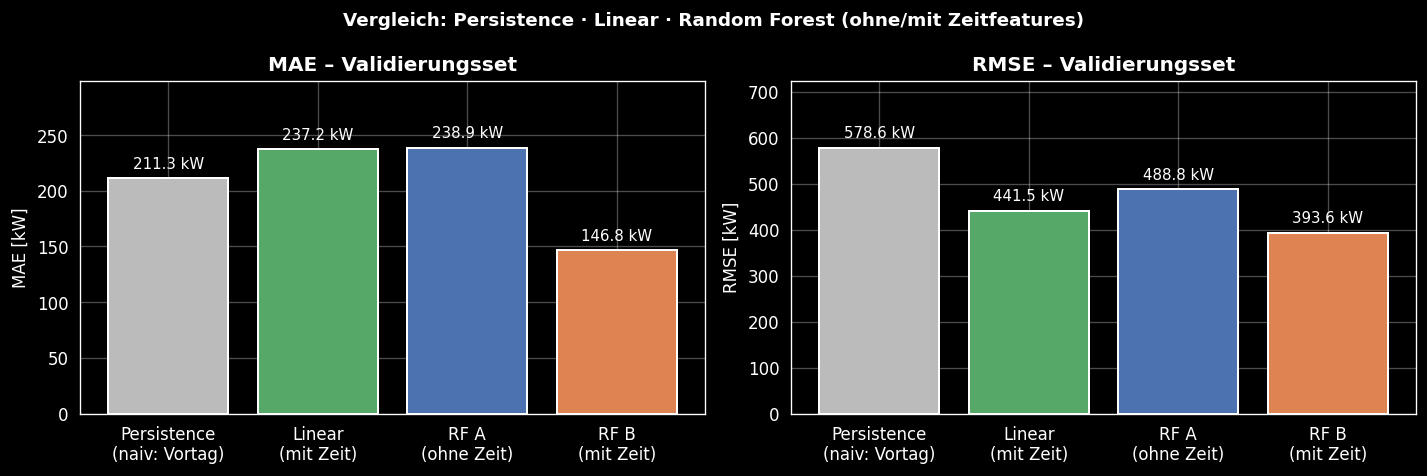

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = ['Persistence (val)', 'Linear – mit Zeit (val)', 'RF A – ohne Zeit (val)', 'RF B – mit Zeit (val)']
labels = ['Persistence\n(naiv: Vortag)', 'Linear\n(mit Zeit)', 'RF A\n(ohne Zeit)', 'RF B\n(mit Zeit)']
colors = ['#bbb', '#55A868', '#4C72B0', '#DD8452']

for ax, metric, title in [
    (axes[0], 'mae',  'MAE – Validierungsset'),
    (axes[1], 'rmse', 'RMSE – Validierungsset'),
]:
    vals = [results_df.loc[m, metric] for m in models]
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, fmt='%.1f kW', padding=4, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric.upper()} [kW]')
    ax.set_ylim(0, max(vals) * 1.25)

plt.suptitle('Vergleich: Persistence · Linear · Random Forest (ohne/mit Zeitfeatures)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 · Beispielwoche

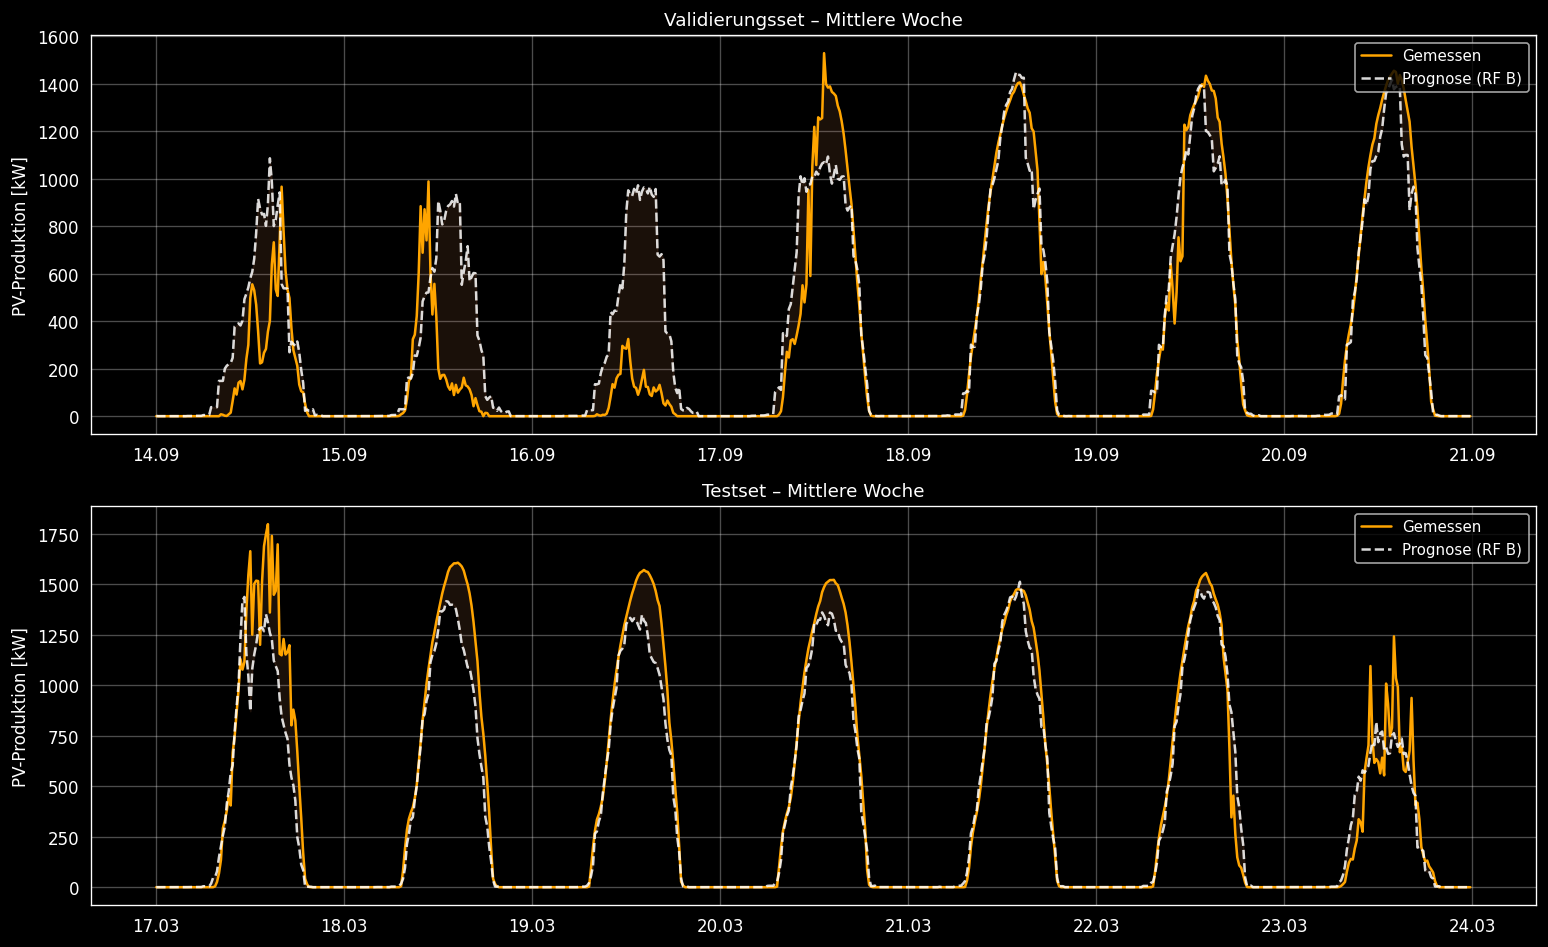

In [8]:
def plot_week(ax, df_split, y_pred, title):
    mid  = df_split['timestamp'].iloc[len(df_split) // 2].floor('D')
    mask = (df_split['timestamp'] >= mid) & (
           df_split['timestamp'] <  mid + pd.Timedelta(days=7))
    sub  = df_split[mask].set_index('timestamp')
    pred = y_pred.reindex(sub.index)
    ax.plot(sub.index, sub[TARGET], label='Gemessen',
            color='orange', linewidth=1.5)
    ax.plot(sub.index, pred, label='Prognose (RF B)',
            color='white', linewidth=1.5, linestyle='--', alpha=0.85)
    ax.fill_between(sub.index, sub[TARGET], pred, alpha=0.12, color='#DD8452')
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylabel('PV-Produktion [kW]')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
plot_week(axes[0], val,  pred_b_val,  'Validierungsset – Mittlere Woche')
plot_week(axes[1], test, pred_b_test, 'Testset – Mittlere Woche')
plt.tight_layout()
plt.show()

## 7 · Residualanalyse

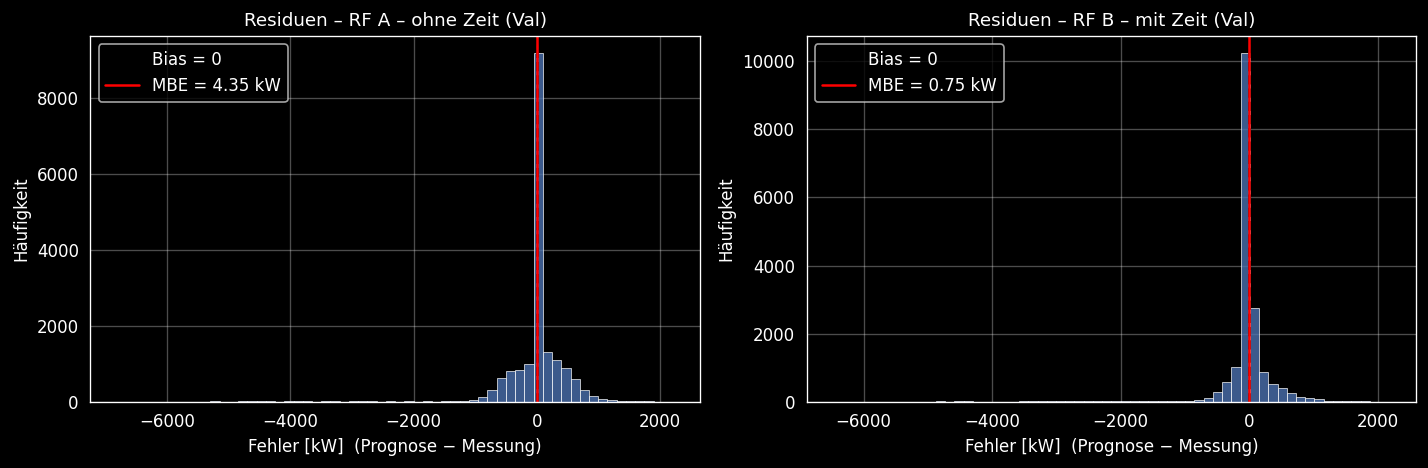

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, yt, yp in [
    (axes[0], 'RF A – ohne Zeit (Val)', y_val, pred_a_val),
    (axes[1], 'RF B – mit Zeit (Val)',  y_val, pred_b_val),
]:
    res = (yp - yt).dropna()
    ax.hist(res, bins=60, color='#4C72B0', edgecolor='white',
            linewidth=0.5, alpha=0.8)
    ax.axvline(0,          color='black', lw=1.5, ls='--', label='Bias = 0')
    ax.axvline(res.mean(), color='red',   lw=1.5, ls='-',
               label=f'MBE = {res.mean():.2f} kW')
    ax.set_title(f'Residuen – {name}', fontsize=11)
    ax.set_xlabel('Fehler [kW]  (Prognose − Messung)')
    ax.set_ylabel('Häufigkeit')
    ax.legend()

plt.tight_layout()
plt.show()

## 8 · Feature Importance

Mittlere Impurity-Reduktion (MDI) über alle Bäume — zeigt welche Features der Random Forest am stärksten nutzt.

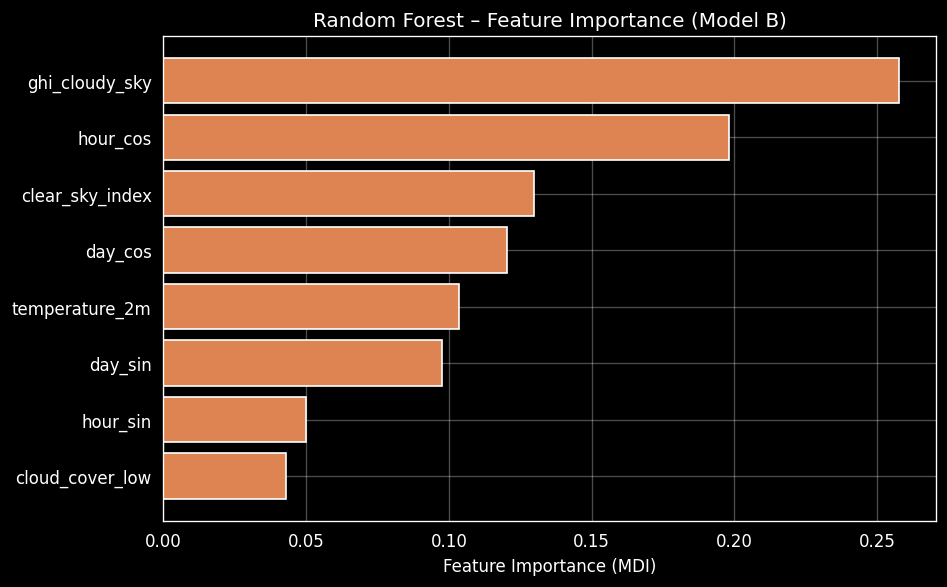

                 importance
feature                    
ghi_cloudy_sky       0.2578
hour_cos             0.1982
clear_sky_index      0.1297
day_cos              0.1205
temperature_2m       0.1034
day_sin              0.0975
hour_sin             0.0498
cloud_cover_low      0.0431


In [10]:
imp_df = pd.DataFrame({
    'feature':    FEATURES_B,
    'importance': model_b.feature_importances_,
}).set_index('feature').sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df.index, imp_df['importance'],
        color='#DD8452', edgecolor='white')
ax.set_xlabel('Feature Importance (MDI)')
ax.set_title('Random Forest – Feature Importance (Model B)', fontsize=12)
plt.tight_layout()
plt.show()

print(imp_df.sort_values('importance', ascending=False).round(4))

## 9 · Forschungshypothesen

| Hypothese | H₀ | H₁ | Ergebnis |
|---|---|---|---|
| **H3** – Zeitfeatures | MAE(ohne Zeit) ≤ MAE(mit Zeit) | MAE(ohne Zeit) > MAE(mit Zeit) | RF B < RF A? |
| **H4** – RF vs. Linear | MAE(RF) ≥ MAE(linear) | MAE(RF) < MAE(linear) | RF B < Linear? |

In [11]:
mae_lin = results_df.loc['Linear – mit Zeit (val)', 'mae']
mae_a   = results_df.loc['RF A – ohne Zeit (val)',  'mae']
mae_b   = results_df.loc['RF B – mit Zeit (val)',   'mae']

print('══ H3 – Einfluss Zeitfeatures (RF) ══')
print(f'  MAE: RF A (ohne Zeit) {mae_a:.1f} kW  →  RF B (mit Zeit) {mae_b:.1f} kW  (Δ = {mae_b - mae_a:+.1f} kW)')
print()
print('══ H4 – RF vs. Lineare Regression ══')
print(f'  MAE: Linear {mae_lin:.1f} kW  →  RF B {mae_b:.1f} kW  (Δ = {mae_b - mae_lin:+.1f} kW)')
print(f'  H4 {"✓ bestätigt" if mae_b < mae_lin else "✗ nicht bestätigt"}')

══ H3 – Einfluss Zeitfeatures (RF) ══
  MAE: RF A (ohne Zeit) 238.9 kW  →  RF B (mit Zeit) 146.8 kW  (Δ = -92.0 kW)

══ H4 – RF vs. Lineare Regression ══
  MAE: Linear 237.2 kW  →  RF B 146.8 kW  (Δ = -90.3 kW)
  H4 ✓ bestätigt


## 10 · Paired t-Tests

Beide Tests einseitig auf Absolutfehlern des Testsets, α = 0.05.

**H3:** MAE(ohne Zeit) > MAE(mit Zeit)  
**H4:** MAE(linear) > MAE(RF)

In [12]:
ALPHA = 0.05

def paired_ttest_one_sided(ae_x, ae_y, label_x, label_y, h_label):
    """Einseitiger gepaarter t-Test: H1 = ae_x > ae_y."""
    common = ae_x.index.intersection(ae_y.index)
    ax_, ay_ = ae_x[common], ae_y[common]
    t_stat, p_two = stats.ttest_rel(ax_, ay_)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2
    print(f'── {h_label} ──')
    print(f'  n = {len(common):,}   |   MAE {label_x}: {ax_.mean():.2f} kW   |   MAE {label_y}: {ay_.mean():.2f} kW')
    print(f'  t = {t_stat:.4f}   p (einseitig) = {p_one:.4e}')
    if p_one < ALPHA:
        print(f'  → H₀ abgelehnt: {label_y} signifikant besser. ✓ bestätigt')
    else:
        print(f'  → H₀ nicht abgelehnt: kein signifikanter Unterschied. ✗ nicht bestätigt')
    print()

ae_a   = (pred_a_test   - y_test).abs().dropna()
ae_b   = (pred_b_test   - y_test).abs().dropna()
ae_lin = (pred_lin_test - y_test).abs().dropna()

paired_ttest_one_sided(ae_a,   ae_b, 'RF A (ohne Zeit)', 'RF B (mit Zeit)',  'H3 – Zeitfeatures')
paired_ttest_one_sided(ae_lin, ae_b, 'Linear',           'RF B (mit Zeit)',  'H4 – RF vs. Linear')

── H3 – Zeitfeatures ──
  n = 17,641   |   MAE RF A (ohne Zeit): 206.42 kW   |   MAE RF B (mit Zeit): 140.23 kW
  t = 39.6308   p (einseitig) = 0.0000e+00
  → H₀ abgelehnt: RF B (mit Zeit) signifikant besser. ✓ bestätigt

── H4 – RF vs. Linear ──
  n = 17,641   |   MAE Linear: 237.27 kW   |   MAE RF B (mit Zeit): 140.23 kW
  t = 72.9130   p (einseitig) = 0.0000e+00
  → H₀ abgelehnt: RF B (mit Zeit) signifikant besser. ✓ bestätigt



## 11 · Ergebnisse speichern

In [13]:
for model_name, yp_val, yp_test, feats in [
    ('random_forest_A_ohne_zeit', pred_a_val, pred_a_test, FEATURES_A),
    ('random_forest_B_mit_zeit',  pred_b_val, pred_b_test, FEATURES_B),
]:
    out = {
        'model':    model_name,
        'features': feats,
        'params':   RF_PARAMS,
        'val':      evaluate(y_val,  yp_val,  P_NOM, y_ref=pers_val),
        'test':     evaluate(y_test, yp_test, P_NOM, y_ref=pers_test),
    }
    path = RESULTS_DIR / f'{model_name}.json'
    with open(path, 'w') as f:
        json.dump(out, f, indent=2)
    print(f'Gespeichert: {path.name}')

Gespeichert: random_forest_A_ohne_zeit.json
Gespeichert: random_forest_B_mit_zeit.json
